# Exponential Probability Distribution

## 1. Definition

## 2. Intuition


## 3. Parameter

## 4. Support

## 5. Probability Mass Function


## 6. Cumulative Distribution Function


## 7. Moments

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf, gammainc, gammaln, betainc, betaln


def validate_sample_size(size):
    if not isinstance(size, (int, np.integer)):
        raise TypeError("size must be an integer.")

    if size < 1:
        raise ValueError("size must be at least 1.")

In [2]:
class Exponential:
    """
    Exponential distribution parameterized by rate lambda_.
    """

    def __init__(self, lambda_: float):
        if not np.isfinite(lambda_) or lambda_ <= 0:
            raise ValueError(
                "lambda_ must be finite and greater than 0."
            )

        self.lambda_ = float(lambda_)

    def pdf(self, x):
        x = np.asarray(x)

        density = np.zeros_like(x, dtype=float)

        valid = x >= 0

        density[valid] = (
            self.lambda_
            * np.exp(-self.lambda_ * x[valid])
        )

        return density

    def cdf(self, x):
        x = np.asarray(x)

        probability = np.zeros_like(x, dtype=float)

        valid = x >= 0

        probability[valid] = (
            1 - np.exp(-self.lambda_ * x[valid])
        )

        return probability

    def mean(self):
        return 1.0 / self.lambda_

    def variance(self):
        return 1.0 / self.lambda_**2

    def sample(self, size=1, random_state=None):
        validate_sample_size(size)

        rng = np.random.default_rng(random_state)
        u = rng.random(size)

        # Inverse-transform sampling
        return -np.log1p(-u) / self.lambda_

    def plot(self, num_points=500, figsize=(10, 4)):
        upper_limit = 6 * self.mean()

        x = np.linspace(0, upper_limit, num_points)

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        axes[0].plot(x, self.pdf(x))
        axes[0].axvline(
            self.mean(),
            linestyle="--",
            label=f"Mean = {self.mean():.2f}",
        )
        axes[0].set_title("Exponential PDF")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Density")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(x, self.cdf(x))
        axes[1].set_title("Exponential CDF")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("Cumulative probability")
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

Exponential mean: 2.0
Exponential samples: [2.97405165 1.15563542 3.91229563 2.39047566 0.19782348]


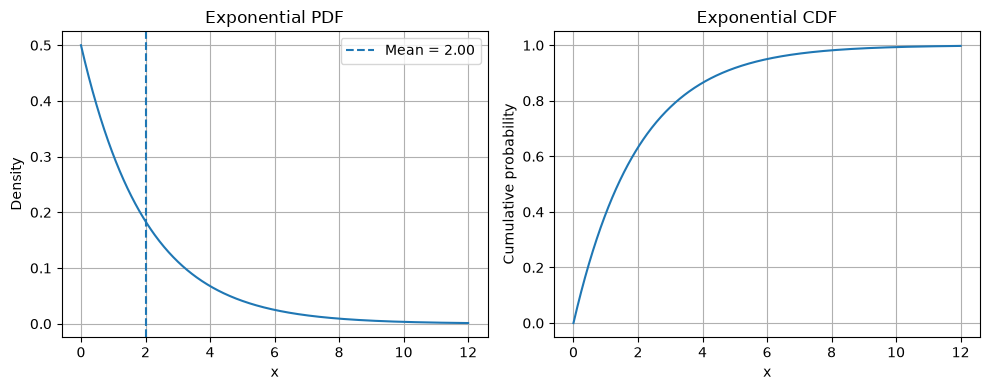

In [3]:
exponential = Exponential(lambda_=0.5)
print("Exponential mean:", exponential.mean())
print(
    "Exponential samples:",
    exponential.sample(5, random_state=42),
)
exponential.plot()